In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             ConfusionMatrixDisplay, classification_report)

sns.set_style("whitegrid")

### Task 1: Data Prep & Baseline

Load the dataset and establish a performance baseline.

1. Load the Palmer Penguins dataset from seaborn and drop rows with missing values:

```python
penguins = sns.load_dataset("penguins").dropna()
```

2. Explore briefly: how many samples and features? What are the three species and their distribution? Which columns are categorical vs. numerical?
3. Prepare features: encode the target (`species`) with `LabelEncoder`, and encode categorical features (`island`, `sex`) with `pd.get_dummies(drop_first=True)`.
4. Split into training and test sets (80/20, `stratify=y`, `random_state=42`).
5. Scale the features using `StandardScaler` (fit on train, transform both).
6. Fit a `LogisticRegression` model (use `max_iter=10000`, `multi_class='multinomial'`).
7. Report **accuracy**, **precision**, **recall**, and **F1 score** on the test set. Print a full `classification_report`.
8. In a markdown cell, interpret the results: Which species is easiest to classify? Which is hardest? Why might that be?


In [2]:
penguins = sns.load_dataset("penguins").dropna()

In [3]:
penguins.shape

(333, 7)

In [4]:
penguins.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

In [5]:
penguins["species"].value_counts()

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

In [6]:
penguins.dtypes

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

The dataset contains 333 samples and 7 columns in total.

There are three penguin species in the dataset:
- Adelie: 146 samples  
- Gentoo: 119 samples  
- Chinstrap: 68 samples  

The data is slightly imbalanced, with Adelie being the most common and Chinstrap the least.


Categorical columns:
- species  
- island  
- sex  

Numerical columns:
- bill_length_mm  
- bill_depth_mm  
- flipper_length_mm  
- body_mass_g  

In [7]:
le = LabelEncoder()
penguins["species_encoded"] = le.fit_transform(penguins["species"])
X = pd.get_dummies(
    penguins.drop(columns=["species", "species_encoded"]),
    drop_first=True
)

y = penguins["species_encoded"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
log_reg = LogisticRegression(solver='lbfgs',max_iter=10000,random_state=42)
log_reg.fit(X_train_scaled, y_train)
 
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_lr, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_lr, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

Accuracy: 0.9850746268656716
Precision: 0.9860696517412935
Recall: 0.9850746268656716
F1 Score: 0.9852010365594893

Classification Report:

              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



The model performs very well, with accuracy close to 99% and consistently high precision, recall, and F1 scores across all classes.

The easiest species to classify is **Gentoo**. It achieves perfect precision and recall, meaning the model separates it from the others without any mistakes. This is likely because Gentoo penguins have clearly distinct physical features, such as larger body mass and flipper length.

The hardest species to classify is **Chinstrap**. Although its recall is perfect, its precision is slightly lower, indicating that some samples from other species are being misclassified as Chinstrap. This suggests there is some overlap in features with other species.

**Adelie** is also slightly harder than Gentoo, as a few samples are misclassified (recall < 1.00). This likely happens because Adelie and Chinstrap share more similar characteristics, making them harder to separate.

Overall, the differences in classification performance are mainly due to how distinct or overlapping the species’ physical features are.

### Task 2: Algorithm Comparison

Train multiple classifiers and compare their performance.

1. Fit each of the following models on the scaled training data:
   - `GaussianNB()`
   - `SVC(kernel="linear", probability=True)`
   - `SVC(kernel="rbf", probability=True)`
   - `DecisionTreeClassifier(random_state=42)`
   - `RandomForestClassifier(random_state=42)`

2. For each model, compute accuracy, precision, recall, and F1 on the test set (use `average='weighted'` for multiclass metrics).
3. Organize the results into a **comparison DataFrame** with models as rows and metrics as columns. Sort by F1 score descending.
4. In a markdown cell, discuss: Which models perform best? Are there any surprises? Why might some algorithms outperform others on this dataset?


In [11]:
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train) 
y_pred_nb = gnb.predict(X_test_scaled)

svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train_scaled, y_train) 
y_pred_svm_lin = svm_linear.predict(X_test_scaled) 

svm_rbf = SVC(kernel='rbf', C=1.0, random_state=42, probability=True)
svm_rbf.fit(X_train_scaled, y_train) 
y_pred_svm_rbf = svm_rbf.predict(X_test_scaled)

dt = DecisionTreeClassifier(max_depth=5,min_samples_split=10,random_state=42)
dt.fit(X_train, y_train) 
y_pred_dt = dt.predict(X_test)

rf = RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42,n_jobs=-1)
rf.fit(X_train, y_train) 
y_pred_rf = rf.predict(X_test)

models = {
    'Logistic Regression': (log_reg, X_test_scaled, y_pred_lr),
    'Naive Bayes': (gnb, X_test_scaled, y_pred_nb),
    'SVM (Linear)': (svm_linear, X_test_scaled, y_pred_svm_lin),
    'SVM (RBF)': (svm_rbf, X_test_scaled, y_pred_svm_rbf),
    'Decision Tree': (dt, X_test, y_pred_dt),
    'Random Forest': (rf, X_test, y_pred_rf),
}
 
results = []
for name, (model, X_eval, y_pred) in models.items():
    report = classification_report(y_test, y_pred, output_dict=True)
    result = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1 Score ': f1_score(y_test, y_pred, average='weighted'),
    }
    results.append(result)
 
comparison = pd.DataFrame(results)
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.985075,0.986070,0.985075,0.985201
1,Naive Bayes,0.776119,0.851175,0.776119,0.760229
2,SVM (Linear),0.985075,0.986070,0.985075,0.985201
3,SVM (RBF),0.985075,0.986070,0.985075,0.985201
4,Decision Tree,0.955224,0.959422,0.955224,0.955400
5,Random Forest,1.000000,1.000000,1.000000,1.000000


The results show clear differences in model performance across algorithms.

The best-performing model is **Random Forest**, achieving perfect scores (1.00) on all metrics. This means it classified every test sample correctly. This happens because Random Forest combines multiple decision trees, allowing it to capture complex patterns while reducing overfitting.

Both **SVM (Linear)** and **SVM (RBF)** perform almost equally well, with very high scores (~0.985 F1). This suggests that the dataset is largely linearly separable, since the linear kernel performs just as well as the more complex RBF kernel.

The **Decision Tree** performs slightly worse (~0.955 F1). This is expected, as a single tree is more prone to overfitting and may not generalize as well as an ensemble method like Random Forest.

The weakest model is **GaussianNB**, with a significantly lower F1 score (~0.76). This is not surprising because Naive Bayes assumes that features are independent and normally distributed, which is not fully true for this dataset. The relationships between features (like body mass and flipper length) likely violate these assumptions.


- **Random Forest** performs best due to its ability to model complex relationships and reduce variance.
- **SVM models** perform very well, indicating the data is close to linearly separable.
- **Decision Tree** is decent but less stable compared to ensemble methods.
- **GaussianNB** struggles due to unrealistic assumptions about the data.


### Task 3: Confusion Matrices & ROC Curves

Visualize how each model makes its decisions.

1. **Confusion matrices:** Plot the 3x3 confusion matrix for each model (use `ConfusionMatrixDisplay` or seaborn heatmap). Arrange them in a grid of subplots for easy comparison. For each, note which species pairs are most frequently confused.

2. **ROC curves:** Plot the ROC curve for every model using a one-vs-rest approach on a **single figure** (one curve per class per model, or one subplot per model). Include the AUC value in each legend entry. Add a diagonal dashed line representing a random classifier.

3. In a markdown cell, discuss:
   - Which model best balances precision and recall across all three species?
   - Which species pair is hardest for the models to distinguish? Why might this be the case given the features?
   - Based on the confusion matrices and ROC curves, which model would you recommend?


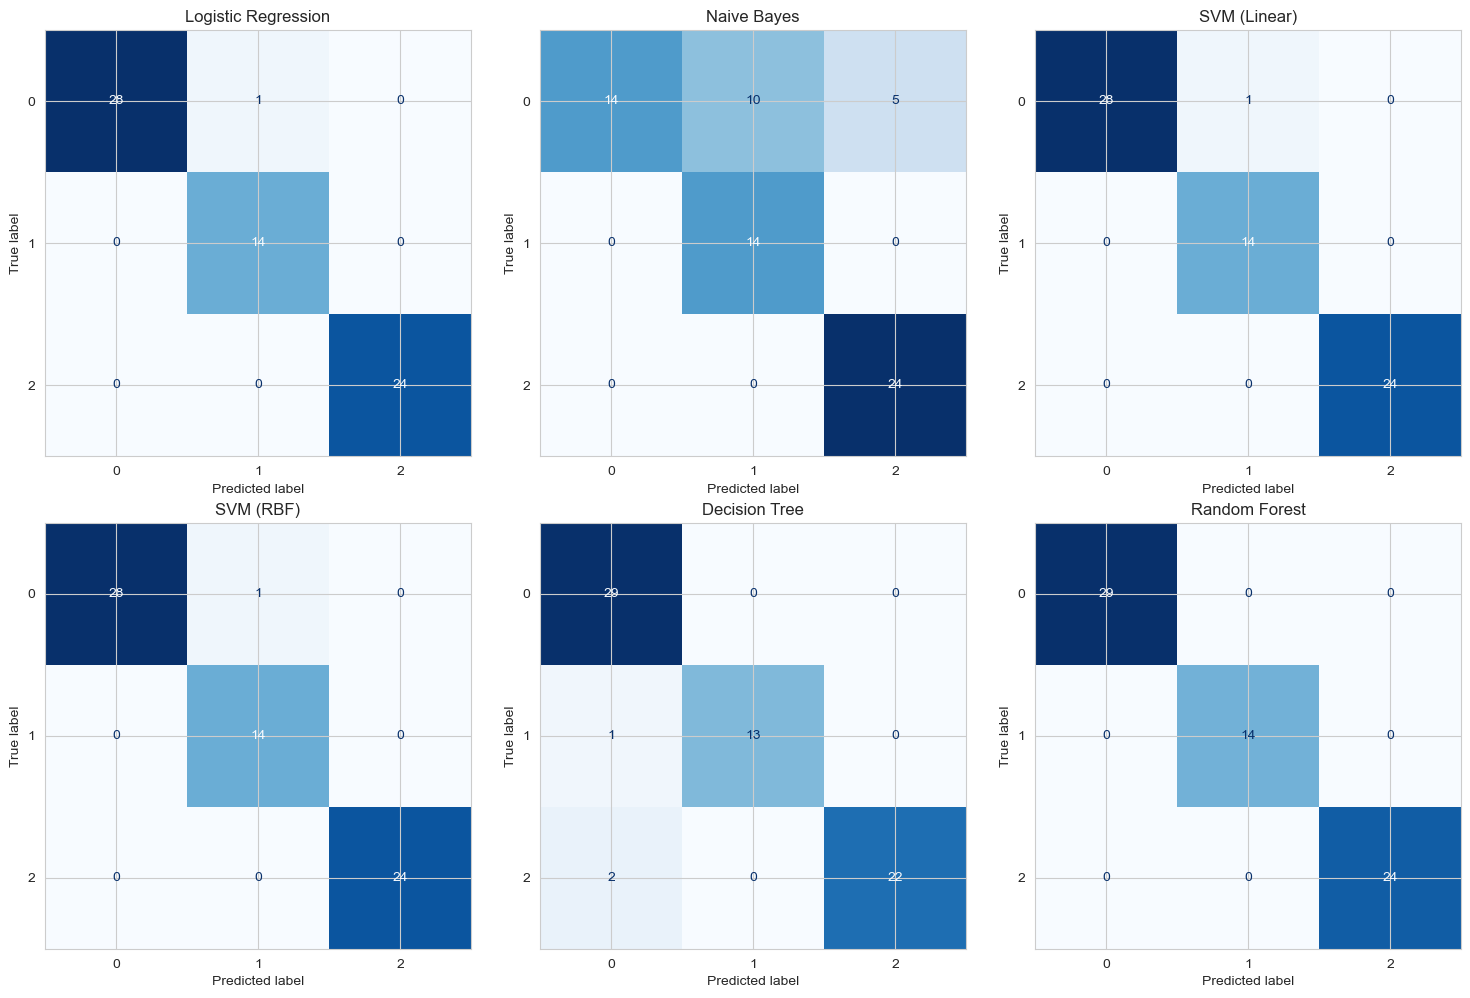

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (name, (model, X_eval, _)) in enumerate(models.items()):
    y_pred = model.predict(X_eval)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        ax=axes[i],
        cmap="Blues",
        colorbar=False
    )
    axes[i].set_title(name)

for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

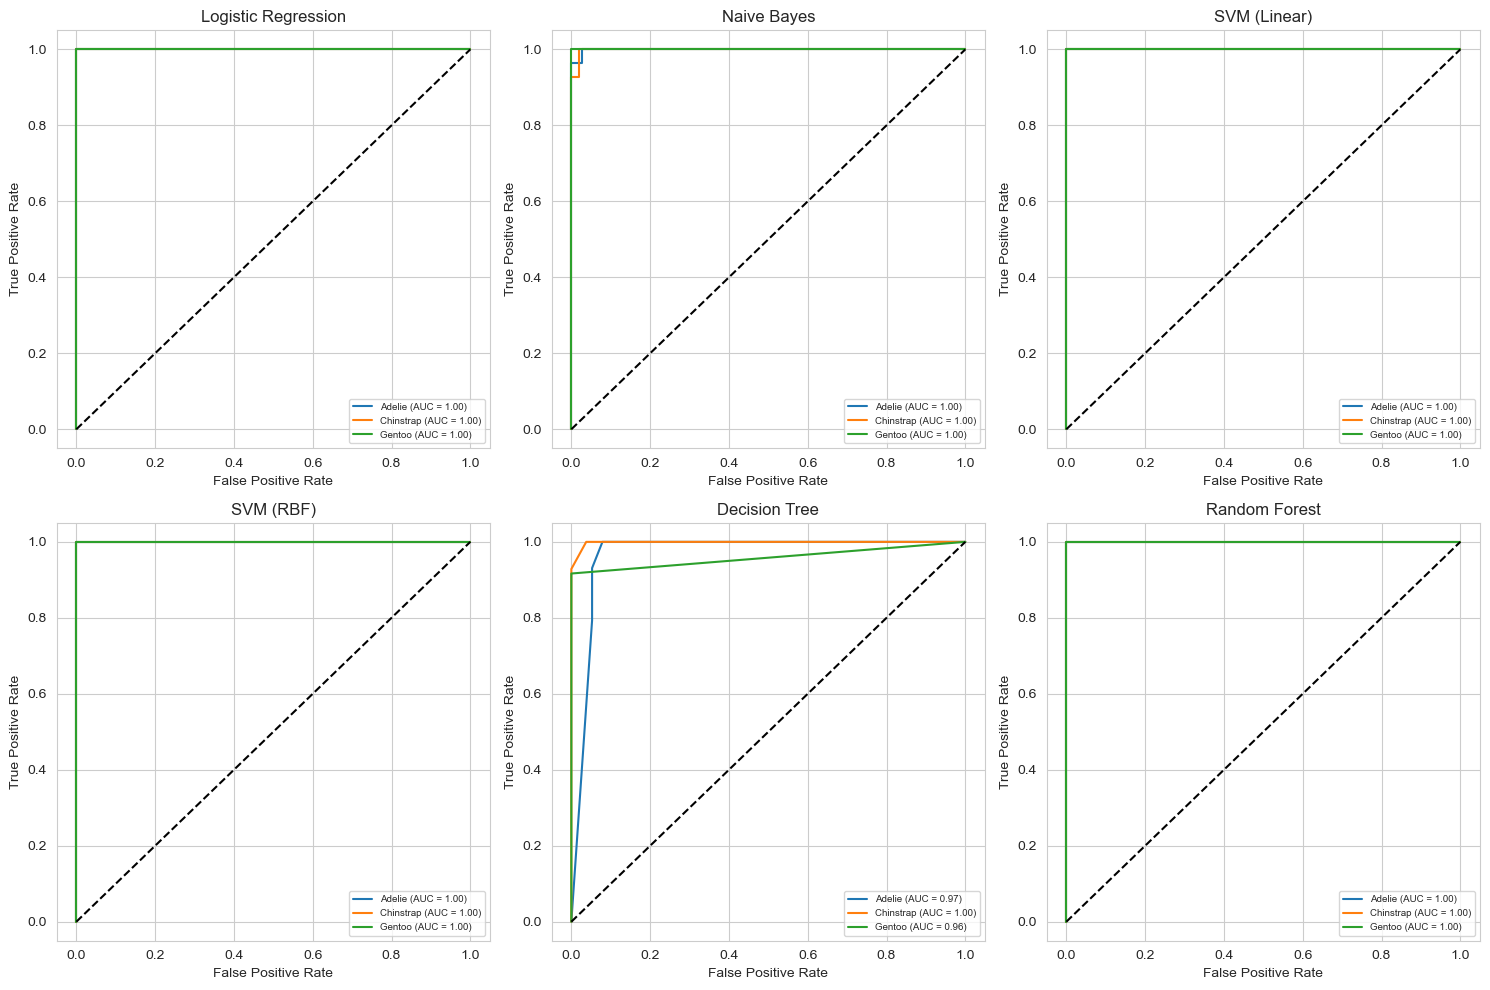

In [13]:
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

models = {
    'Logistic Regression': (log_reg, X_test_scaled),
    'Naive Bayes': (gnb, X_test_scaled),
    'SVM (Linear)': (svm_linear, X_test_scaled),
    'SVM (RBF)': (svm_rbf, X_test_scaled),
    'Decision Tree': (dt, X_test),
    'Random Forest': (rf, X_test),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, (model, X_eval)) in enumerate(models.items()):
    ax = axes[idx]
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_eval)
    else:
        y_score = model.decision_function(X_eval)

    
    for i, species in enumerate(le.classes_):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)

        ax.plot(fpr, tpr, label=f'{species} (AUC = {roc_auc:.2f})')

  
    ax.plot([0, 1], [0, 1], 'k--')

    ax.set_title(name)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=7)


for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Based on the confusion matrices, Logistic Regression, SVM (Linear), SVM (RBF), and Random Forest achieve nearly perfect classification across all three species. These models make either no errors or only very minor ones, indicating a strong balance between precision and recall. This is further supported by the ROC curves, where the AUC values for these models are approximately 1.00 for all classes.

In contrast, the Naive Bayes model shows noticeably more misclassifications. In particular, class 0 is sometimes confused with other classes. This can be explained by the model’s assumption that features are independent, which is often not true in real-world datasets where features may be correlated.

The most difficult pair of species to distinguish appears to be class 0 and class 1 (e.g., Adelie and Chinstrap). These species likely share similar feature values (such as bill length or flipper length), causing some models to confuse them. This suggests that the available features are not fully sufficient to clearly separate these two classes.

The Decision Tree model also makes a few errors, such as misclassifying some instances of class 2 as class 0. This may be due to its relatively simple structure, which can limit its ability to generalize compared to more advanced models.

Overall, considering both the confusion matrices and ROC curves, Logistic Regression, SVM, and Random Forest provide the best performance. Among them, Random Forest is a strong choice for practical use, as it combines high accuracy with robustness and good generalization.

### Task 4: Hyperparameter Exploration

Tune the best-performing model from Task 2.

1. Select the best model based on your Task 2 results.
2. Define a hyperparameter grid with **at least 3 hyperparameters** to tune. For example, if RandomForest was best:

```python
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10]
}
```

3. Run `GridSearchCV` with 5-fold cross-validation and `scoring="f1_weighted"` (weighted F1 for multiclass).
4. Report the **best parameters** and the **best cross-validation F1 score**.
5. Evaluate the tuned model on the test set. Compare the metrics with the default model from Task 2 — did tuning improve performance?
6. In a markdown cell, reflect: Was the improvement significant? Is there a risk of overfitting to the validation folds? When is hyperparameter tuning most impactful?


In [14]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10]
}
grid_search = GridSearchCV(estimator=rf,param_grid=param_grid,cv=5,scoring="f1_weighted",n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}

Best Cross-Validation F1 Score:
0.9961656161968262


In [15]:
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

print("Tuned Model Performance:\n")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned, average="weighted"))
print("Recall:", recall_score(y_test, y_pred_tuned, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred_tuned, average="weighted"))

Tuned Model Performance:

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [16]:
y_pred_default = rf.fit(X_train, y_train).predict(X_test)

import pandas as pd

comparison_df = pd.DataFrame([
    {
        "Model": "Random Forest (Default)",
        "Accuracy": accuracy_score(y_test, y_pred_default),
        "Precision": precision_score(y_test, y_pred_default, average="weighted"),
        "Recall": recall_score(y_test, y_pred_default, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred_default, average="weighted")
    },
    {
        "Model": "Random Forest (Tuned)",
        "Accuracy": accuracy_score(y_test, y_pred_tuned),
        "Precision": precision_score(y_test, y_pred_tuned, average="weighted"),
        "Recall": recall_score(y_test, y_pred_tuned, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred_tuned, average="weighted")
    }
])

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest (Default),1.0,1.0,1.0,1.0
1,Random Forest (Tuned),1.0,1.0,1.0,1.0


The hyperparameter tuning process resulted in a best cross-validation F1 score of approximately 0.996, with optimal parameters including a relatively small number of trees and no restriction on tree depth. However, when evaluating the tuned model on the test set, the performance remained identical to the default model, achieving perfect scores (1.00) across all metrics.

This indicates that the improvement from tuning was not significant. The model had already reached its performance ceiling on this dataset, meaning that further optimization of hyperparameters could not yield measurable gains. This is likely due to the dataset being relatively simple and well-separated, allowing even the default configuration of Random Forest to perform optimally.

Although cross-validation helps ensure robustness, there is still a potential risk of overfitting to the validation folds during GridSearchCV, especially when exploring multiple parameter combinations. However, in this case, the consistency between cross-validation performance and test results suggests that the model is generalizing well rather than overfitting.

Hyperparameter tuning is most impactful when dealing with more complex datasets, where patterns are harder to learn and the default model does not already achieve near-perfect performance. In such cases, tuning can significantly improve model generalization and predictive accuracy. In contrast, for simpler datasets like this one, the benefits of tuning are often minimal.